In [1]:
import stellarator as stl
import spline as sp
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import plotly.graph_objects as go

In [3]:
case_path = '/home/emgreen/simulations/stellarator/183281/uniform/no_Er/'
fname="spdata.dat"
(sgn,psiw,ped,spdtheta,spdpsi,lsp,lst,torpsi,qpsi,gpsi,cpsi,rpsi,ntor,bcn,bsn,xcn,xsn,zcn,zsn,fcn,fsn,ndim,ndim_total,r0,b0,nfp)=stl.read_spdata(case_path+fname,0,9)

GTC numerical equilibrium model #3
[59, 199]
[0.39434104059]
[14, 10]
VMEC DIMENSION READ:
lsp= 59 lst= 200 ndim_total= 14 psiw= 0.39434104059
In zeta out system: sgn(psip)= 1 torpsi(1,lsp)= 0.52110496226 gpsi(1,1)= 9.9709337823 fielddir= 0
Using VMEC: R0= 3.7714228069050004 B0= 2.637291397335 ndim= 14


In [3]:
qpsi = sp.mk_splinefunction(lsp,spdpsi,qpsi,0)
rpsi = sp.mk_splinefunction(lsp,spdpsi,rpsi,1)
qpsi(psiw*0.5)

np.float64(1.0920286397771606)

In [4]:
nzsp_sec=7
mtoroidal=15
lszeta=mtoroidal*nzsp_sec+1
toroidaln=5
spdzeta = 2*np.pi/toroidaln/(lszeta-1)
ndim=14
noaxis=1
ndim_total=14
#Each of these will take a while
#spx3d,spx=stl.construct_3d_spline(sgn,psiw,ntor,lsp,lst,lszeta,toroidaln,ndim,noaxis,ndim_total,xcn,xsn)
#spz3d,spz=stl.construct_3d_spline(sgn,psiw,ntor,lsp,lst,lszeta,toroidaln,ndim,noaxis,ndim_total,zcn,zsn)
spb3d,spb=stl.construct_3d_spline(sgn,psiw,ntor,lsp,lst,lszeta,toroidaln,ndim,noaxis,ndim_total,bcn,bsn)
#spf3d,spf=stl.construct_3d_spline(sgn,psiw,ntor,lsp,lst,lszeta,toroidaln,ndim,noaxis,ndim_total,fcn,fsn)

Completed mapping to boozer coordinates
begin constructing spline


In [5]:
def cartesian_boozer(psi,theta,zeta):
    #returns cartesian coordinates of point in boozer coordinates
    #requires all 4 3d sspline functions
    r = spx(psi,theta,zeta)
    z = spz(psi,theta,zeta)
    f = -spf(psi,theta,zeta)-zeta
    x = r*np.cos(f)
    y = r*np.sin(f)
    return x,y,z


<>:9: SyntaxWarning: invalid escape sequence '\z'
<>:9: SyntaxWarning: invalid escape sequence '\z'
/tmp/ipykernel_30780/1761606491.py:9: SyntaxWarning: invalid escape sequence '\z'
  plt.title('magnetic surface on $\zeta=0$, $\psi/\psi_W\in[%.2f,%.2f]$'%(start/lsp,end/lsp))


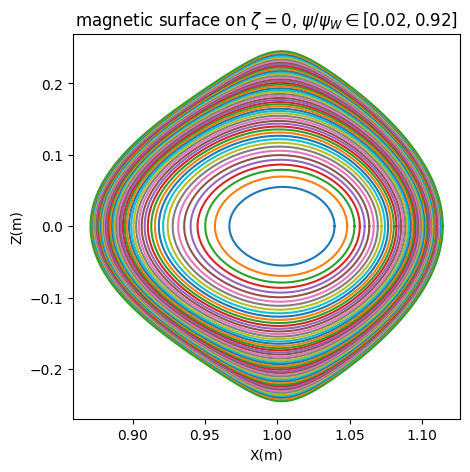

In [6]:
plt.figure(figsize=(5,5),dpi=100)
start=1
end=lsp-5
for i in range(start,end):
    plt.plot(spx3d[0,i,:,0],spz3d[0,i,:,0])

plt.xlabel('X(m)')
plt.ylabel('Z(m)')
plt.title('magnetic surface on $\zeta=0$, $\psi/\psi_W\in[%.2f,%.2f]$'%(start/lsp,end/lsp))
plt.show()

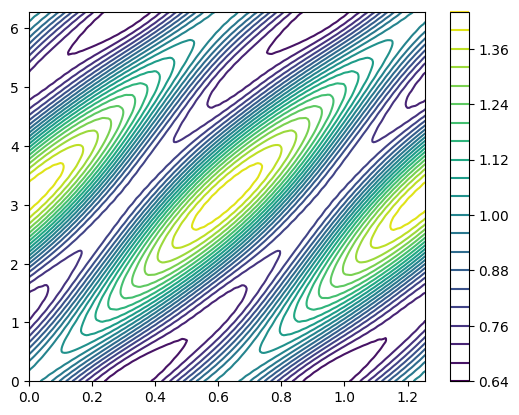

In [5]:
psi = 0.7*psiw
sp.contour_sp(spb, 5,psi = psi)

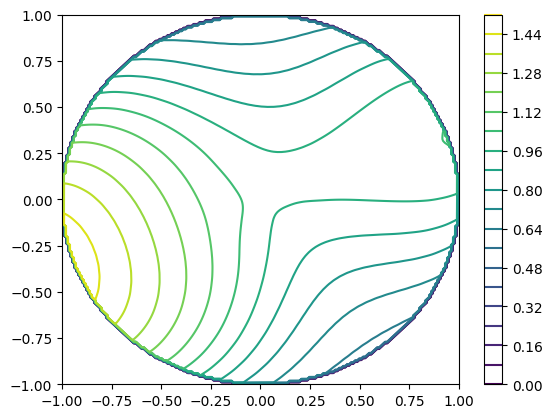

In [7]:
sp.contour_sp(spb, 5,zeta =0.7,psiw=psiw)